# 02.5 - Vanilla Tabular Baseline (XGBoost)

Before developing the complex Phase III Deep Sequence architecture, best practices dictate establishing a deterministic tabular baseline. This "Vanilla" model provides a lower bound for performance metrics and proves the predictive power of our Gold Layer heuristics.

**Objectives:**
1. **Data Isolation:** Filter the Gold Layer to utilize ONLY the labeled cohort (`IS_LABELED == True`).
2. **Preprocessing:** Encode the target segments (`ATSEG`) and apply `RobustScaler` to the temporal heuristics to neutralize extreme outliers (Key Opinion Leaders).
3. **Imbalance Handling:** Dynamically compute sample weights to penalize the model for missing minority classes.
4. **Validation Strategy:** Train an XGBoost Classifier using a strict 5-Fold Stratified Cross-Validation to ensure robust, out-of-sample performance metrics without data leakage.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Ingestion & Isolation
# ==========================================
print("Loading Gold Layer Heuristics...")
df = pd.read_parquet('data/gold_heuristic_features.parquet')

# Isolate the ground-truth labeled cohort
labeled_df = df[df['IS_LABELED'] == True].reset_index(drop=True)
print(f"Isolated labeled cohort: {len(labeled_df)} HCPs")

# Define features (X) and target (y)
# We drop identifiers, text demographics, and the label flag
drop_cols = ['NUEVO_ID', 'IS_LABELED', 'ATSEG', 'SPECIALTY']
X = labeled_df.drop(columns=[col for col in drop_cols if col in labeled_df.columns])
y = labeled_df['ATSEG']

print(f"Feature matrix shape: {X.shape}")

# ==========================================
# 2. Preprocessing & Scaling
# ==========================================
print("Encoding target variable and scaling features...")

# Encode Target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

# Scale Features (Mandatory RobustScaler due to EDA Skewness findings)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Preprocessing complete. Ready for training.")

Loading Gold Layer Heuristics...
Isolated labeled cohort: 11899 HCPs
Feature matrix shape: (11899, 24)
Encoding target variable and scaling features...
Preprocessing complete. Ready for training.


## Model Training & Evaluation (Stratified K-Fold)

Because our labeled dataset is relatively small (~1,000 rows) and imbalanced, a standard train/test split is highly susceptible to variance. We will use a **5-Fold Stratified Cross Validation** to evaluate the XGBoost model. This ensures every HCP is used for testing exactly once, and class proportions are maintained across all folds.

Initializing Stratified 5-Fold Cross-Validation...

Training and evaluating folds...
Fold 1 - Macro F1-Score: 0.5508
Fold 2 - Macro F1-Score: 0.5379
Fold 3 - Macro F1-Score: 0.5570
Fold 4 - Macro F1-Score: 0.5487
Fold 5 - Macro F1-Score: 0.5493

--- Cross-Validation Complete ---
Mean Macro F1-Score: 0.5487 (+/- 0.0062)

Global Classification Report (Aggregated across all folds):
              precision    recall  f1-score   support

       SEG_A       0.78      0.71      0.74      6406
       SEG_B       0.52      0.53      0.53      3349
       SEG_C       0.34      0.42      0.38      2144

    accuracy                           0.61     11899
   macro avg       0.55      0.55      0.55     11899
weighted avg       0.63      0.61      0.62     11899



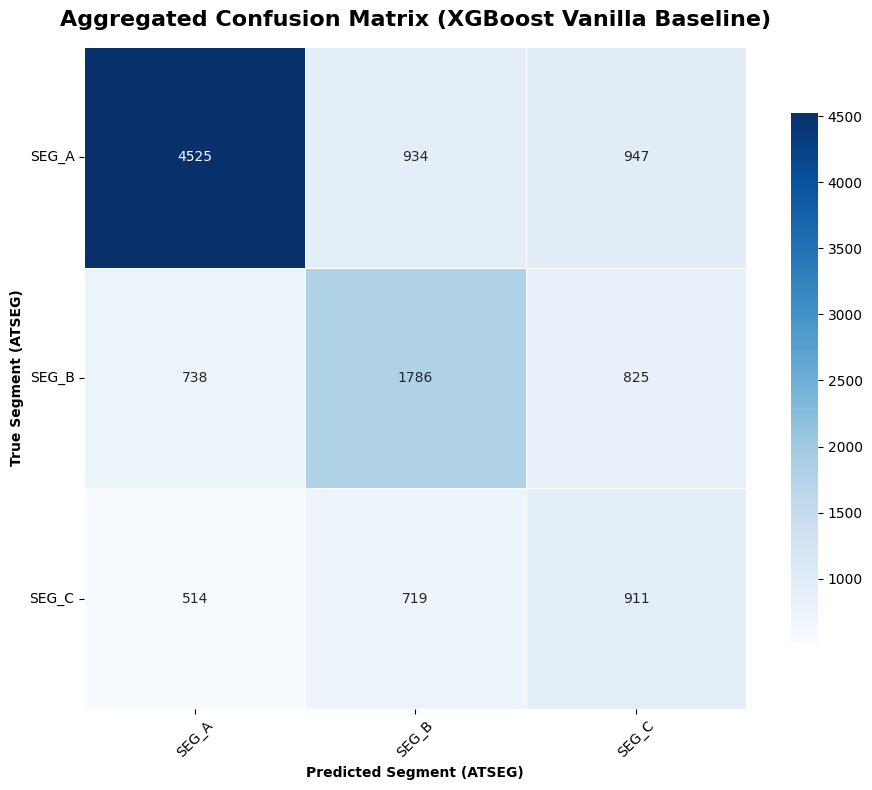


VANILLA BASELINE COMPLETE.
This establishes our deterministic benchmark. Phase III (Deep Sequence Learning) must surpass these metrics.


In [3]:
# ==========================================
# 3. Model Initialization & Cross-Validation Setup
# ==========================================
print("Initializing Stratified 5-Fold Cross-Validation...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize arrays to store true and predicted labels for the aggregate confusion matrix
all_y_true = []
all_y_pred = []
fold_f1_scores = []

# Initialize XGBoost with standard parameters
# eval_metric='mlogloss' handles multi-class probability outputs
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

# ==========================================
# 4. Training Loop
# ==========================================
print("\nTraining and evaluating folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_encoded), 1):
    # Split data
    X_train, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    
    # Compute dynamic sample weights to combat class imbalance (Step 6 EDA Directive)
    weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    # Train model
    xgb_model.fit(X_train, y_train, sample_weight=weights)
    
    # Predict on validation fold
    y_pred = xgb_model.predict(X_val)
    
    # Store predictions for aggregate metrics
    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)
    
    # Calculate fold metric (F1-Macro is critical for imbalanced multi-class)
    fold_f1 = f1_score(y_val, y_pred, average='macro')
    fold_f1_scores.append(fold_f1)
    
    print(f"Fold {fold} - Macro F1-Score: {fold_f1:.4f}")

print(f"\n--- Cross-Validation Complete ---")
print(f"Mean Macro F1-Score: {np.mean(fold_f1_scores):.4f} (+/- {np.std(fold_f1_scores):.4f})")

# ==========================================
# 5. Global Evaluation & Confusion Matrix
# ==========================================
print("\nGlobal Classification Report (Aggregated across all folds):")
print(classification_report(all_y_true, all_y_pred, target_names=class_names))

# Plotting the Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_y_true, all_y_pred)

# Visualize using Seaborn Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            square=True, linewidths=.5, cbar_kws={"shrink": .80})

plt.title('Aggregated Confusion Matrix (XGBoost Vanilla Baseline)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Segment (ATSEG)', fontweight='bold')
plt.ylabel('True Segment (ATSEG)', fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nVANILLA BASELINE COMPLETE.")
print("This establishes our deterministic benchmark. Phase III (Deep Sequence Learning) must surpass these metrics.")

## Step: Dimensionality Reduction & Cluster Visualization

To understand why our XGBoost model is achieving a ~0.55 Macro F1-Score and confusing `SEG_B` with `SEG_C`, we must visualize the high-dimensional feature space of our Gold Layer. 

We will use two standard dimensionality reduction techniques to compress our 24+ heuristic features into a 2D plane:
1. **PCA (Principal Component Analysis):** A linear transformation that maximizes variance.
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding):** A non-linear algorithm excellent for visualizing distinct clusters in complex datasets.

Executing Dimensionality Reduction to visualize feature space clusters...
Note: t-SNE is computationally expensive and may take a minute on ~12k rows.


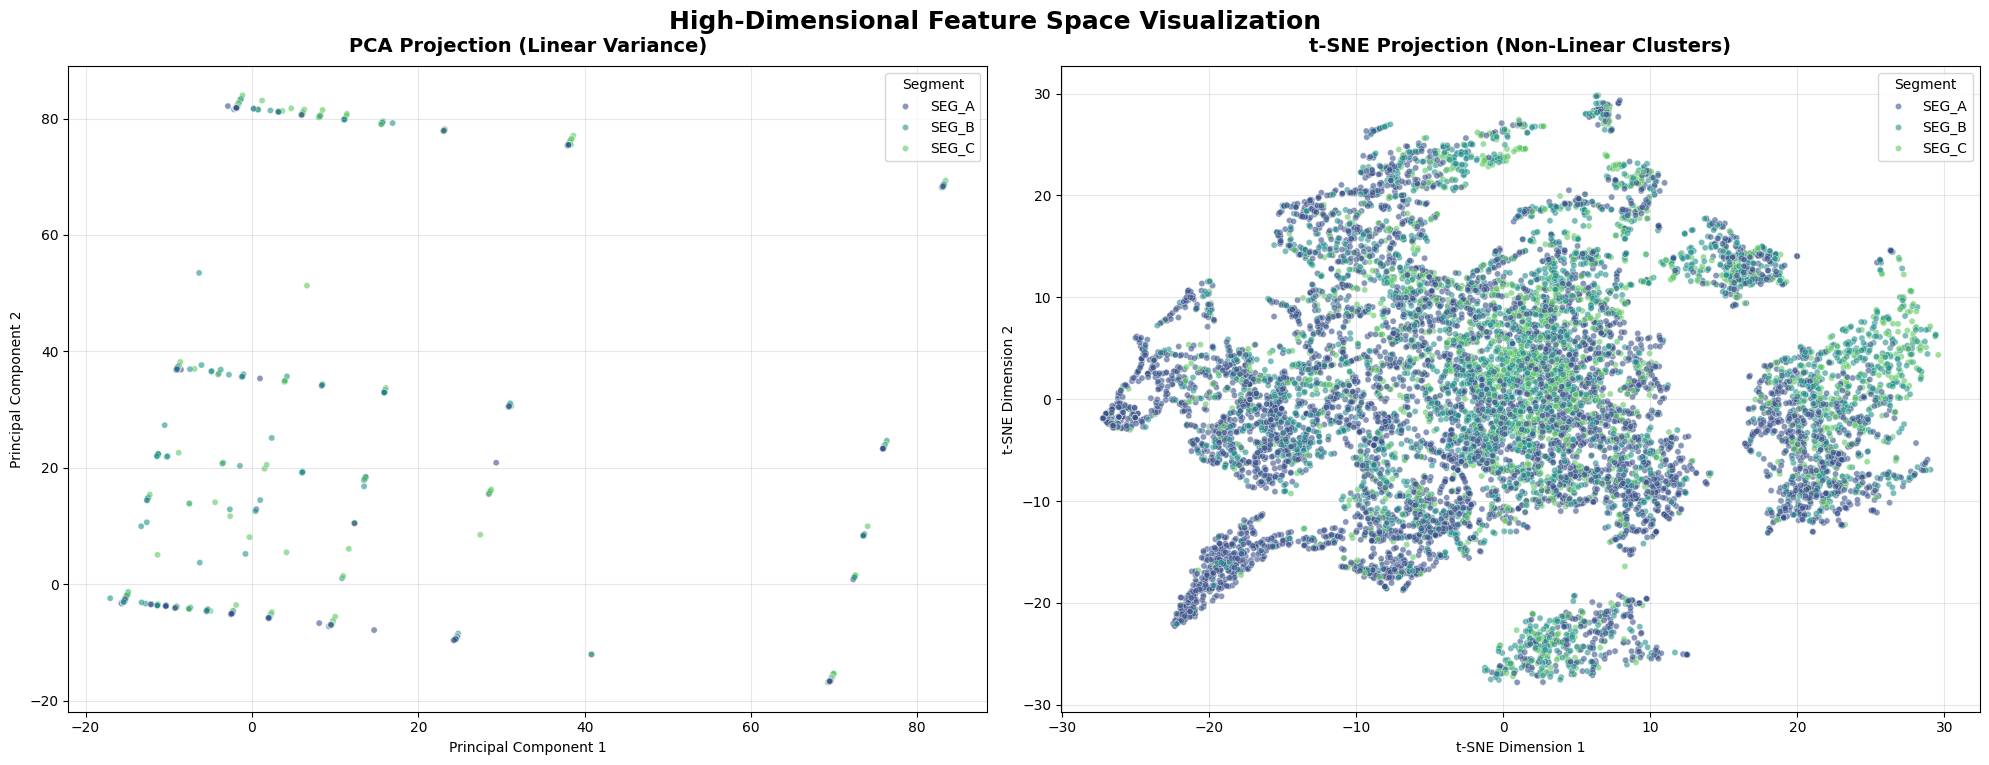


--- VISUAL DIAGNOSTIC ---
If the segments (colors) appear highly mixed and overlapping, it visually explains
the confusion matrix results (specifically the blending of SEG_B and SEG_C).
CONCLUSION: This proves that aggregated tabular heuristics lose critical temporal data.
This is the exact mathematical justification needed to proceed to Phase III:
Building a Deep Sequence model (1D-CNN or TS2Vec) to extract native temporal embeddings.


In [5]:
# ==========================================
# 6. Dimensionality Reduction & Visualization
# ==========================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Executing Dimensionality Reduction to visualize feature space clusters...")
print("Note: t-SNE is computationally expensive and may take a minute on ~12k rows.")

# 1. PCA (Fast, linear separation)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

# 2. t-SNE (Slower, non-linear cluster separation)
# Using 'pca' initialization is a best practice for t-SNE stability and speed
tsne = TSNE(n_components=3, random_state=42, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(X_scaled)

# Create a temporary DataFrame for plotting
plot_df = pd.DataFrame({
    'PCA_1': pca_result[:, 0],
    'PCA_2': pca_result[:, 1],
    'tSNE_1': tsne_result[:, 0],
    'tSNE_2': tsne_result[:, 1],
    'Segment': y # Ground truth labels
})

# ==========================================
# Plotting the Projections
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('High-Dimensional Feature Space Visualization', fontsize=18, fontweight='bold', y=0.95)

# --- PCA Plot ---
sns.scatterplot(
    x='PCA_1', y='PCA_2',
    hue='Segment',
    palette='viridis', # Beautiful color palette
    data=plot_df,
    legend="full",
    alpha=0.6, # Slight transparency to see overlapping points
    s=20, # Marker size
    ax=axes[0]
)
axes[0].set_title('PCA Projection (Linear Variance)', fontweight='bold', fontsize=14, pad=10)
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True, alpha=0.3)

# --- t-SNE Plot ---
sns.scatterplot(
    x='tSNE_1', y='tSNE_2',
    hue='Segment',
    palette='viridis',
    data=plot_df,
    legend="full",
    alpha=0.6,
    s=20,
    ax=axes[1]
)
axes[1].set_title('t-SNE Projection (Non-Linear Clusters)', fontweight='bold', fontsize=14, pad=10)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# ==========================================
# Diagnostic Output
# ==========================================
print("\n--- VISUAL DIAGNOSTIC ---")
print("If the segments (colors) appear highly mixed and overlapping, it visually explains")
print("the confusion matrix results (specifically the blending of SEG_B and SEG_C).")
print("CONCLUSION: This proves that aggregated tabular heuristics lose critical temporal data.")
print("This is the exact mathematical justification needed to proceed to Phase III:")
print("Building a Deep Sequence model (1D-CNN or TS2Vec) to extract native temporal embeddings.")